In [1]:
import os
import rasterio
import rioxarray as rxr
import matplotlib.pyplot as plt

In [5]:
dir = "C:/Users/RDCRLSMC/Desktop/IDAHO_ALS/2026"

raster_dict = {}
for root, dirs, files in os.walk(dir):
    for filename in files:
        if "50m_clip" in filename:
            full_path = os.path.join(root, filename)
            result = filename.split("_")
            name = result[0]
            raster_dict[name] = os.path.abspath(full_path)

print(raster_dict)

{'20251203': 'C:\\Users\\RDCRLSMC\\Desktop\\IDAHO_ALS\\2026\\20251203_MCS_50m_clip.tif', '20251213': 'C:\\Users\\RDCRLSMC\\Desktop\\IDAHO_ALS\\2026\\20251213_MCS_50m_clip.tif', '20251220': 'C:\\Users\\RDCRLSMC\\Desktop\\IDAHO_ALS\\2026\\20251220_MCS_50m_clip.tif', '20260110': 'C:\\Users\\RDCRLSMC\\Desktop\\IDAHO_ALS\\2026\\20260110_MCS_50m_clip.tif', '20260126': 'C:\\Users\\RDCRLSMC\\Desktop\\IDAHO_ALS\\2026\\20260126_MCS_50m_clip.tif', '20260131': 'C:\\Users\\RDCRLSMC\\Desktop\\IDAHO_ALS\\2026\\20260131_MCS_50m_clip.tif', '20260207': 'C:\\Users\\RDCRLSMC\\Desktop\\IDAHO_ALS\\2026\\20260207_MCSv2_50m_clip.tif', '20260222': 'C:\\Users\\RDCRLSMC\\Desktop\\IDAHO_ALS\\2026\\20260222_MCS_50m_clip.tif', '20260226': 'C:\\Users\\RDCRLSMC\\Desktop\\IDAHO_ALS\\2026\\20260226_MCS_50m_clip.tif', '20260303': 'C:\\Users\\RDCRLSMC\\Desktop\\IDAHO_ALS\\2026\\20260303_MCS_50m_clip.tif', '20260315': 'C:\\Users\\RDCRLSMC\\Desktop\\IDAHO_ALS\\2026\\20260315_MCS_50m_clip.tif', '20260404': 'C:\\Users\\RDCRL

In [6]:
for i, (date, raster) in enumerate(raster_dict.items()):
    print(os.path.join(dir, raster))
    print(type(raster))
    with rasterio.open(os.path.join(dir, raster)) as src:
        print(src.crs)

C:\Users\RDCRLSMC\Desktop\IDAHO_ALS\2026\20251203_MCS_50m_clip.tif
<class 'str'>
EPSG:32611
C:\Users\RDCRLSMC\Desktop\IDAHO_ALS\2026\20251213_MCS_50m_clip.tif
<class 'str'>
EPSG:32611
C:\Users\RDCRLSMC\Desktop\IDAHO_ALS\2026\20251220_MCS_50m_clip.tif
<class 'str'>
EPSG:32611
C:\Users\RDCRLSMC\Desktop\IDAHO_ALS\2026\20260110_MCS_50m_clip.tif
<class 'str'>
EPSG:32611
C:\Users\RDCRLSMC\Desktop\IDAHO_ALS\2026\20260126_MCS_50m_clip.tif
<class 'str'>
EPSG:32611
C:\Users\RDCRLSMC\Desktop\IDAHO_ALS\2026\20260131_MCS_50m_clip.tif
<class 'str'>
EPSG:32611
C:\Users\RDCRLSMC\Desktop\IDAHO_ALS\2026\20260207_MCSv2_50m_clip.tif
<class 'str'>
EPSG:32611
C:\Users\RDCRLSMC\Desktop\IDAHO_ALS\2026\20260222_MCS_50m_clip.tif
<class 'str'>
EPSG:32611
C:\Users\RDCRLSMC\Desktop\IDAHO_ALS\2026\20260226_MCS_50m_clip.tif
<class 'str'>
EPSG:32611
C:\Users\RDCRLSMC\Desktop\IDAHO_ALS\2026\20260303_MCS_50m_clip.tif
<class 'str'>
EPSG:32611
C:\Users\RDCRLSMC\Desktop\IDAHO_ALS\2026\20260315_MCS_50m_clip.tif
<class 'str

C:\Users\RDCRLSMC\AppData\Local\Temp\3\ipykernel_12112\1840534821.py:29: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


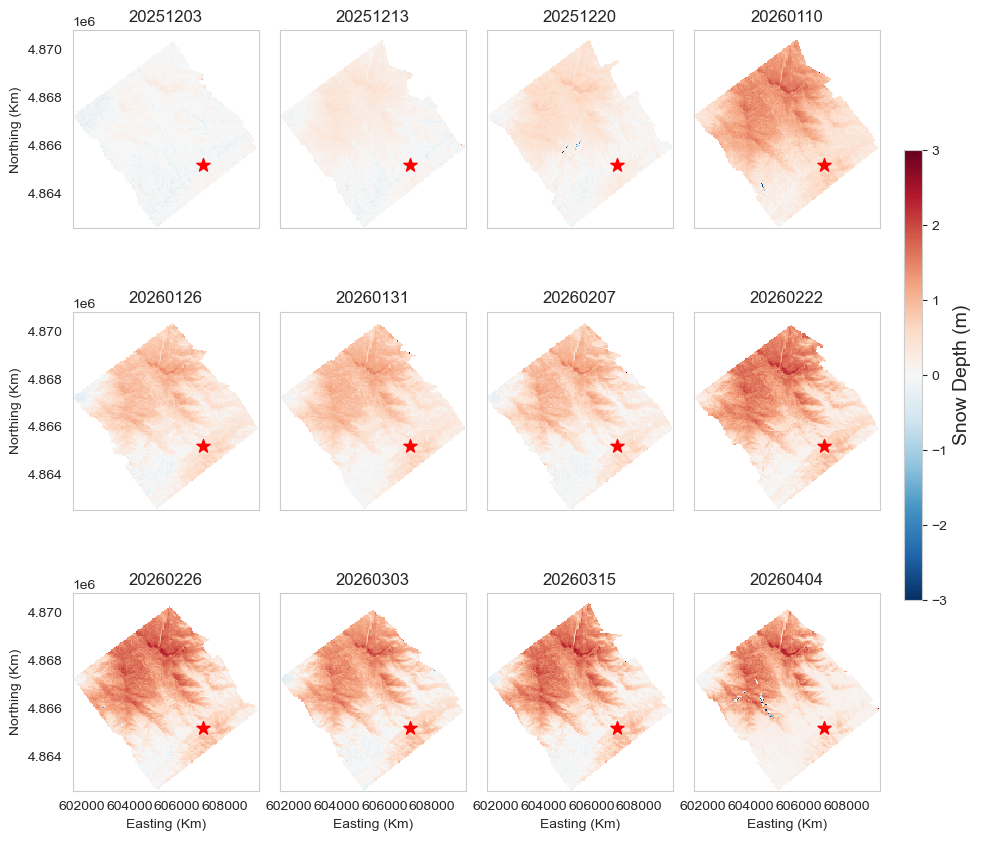

In [4]:
import matplotlib.colors as mcolors
import matplotlib.cm as cm

vcenter = 0
vmin = -3
vmax = 3
normalize = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=vcenter, vmax=vmax)
colormap = cm.RdBu_r

fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(9,9), sharex=True, sharey=True)
for i, (date, raster) in enumerate(raster_dict.items()):
    if i < len(raster_dict.items()):
        ax = axes.flatten()[i]
        snow_depth = rxr.open_rasterio(raster, masked=True)
        snow_depth = snow_depth.where(snow_depth > -5)
        im = snow_depth.plot(ax=ax, cmap=colormap, vmin=vmin, vmax=vmax, add_colorbar=False, robust=True)
        # gdf_20220217.plot(ax=ax, color='none', edgecolor='red')
        ax.scatter(607084.3493239387, 4865185.334007569, marker='*', s=100, color="red", label='SNOTEL')
        ax.set_title(date)
        ax.set_aspect('equal')
        ax.set_xlabel('Easting (Km)')
        ax.set_ylabel('Northing (Km)')
        ax.label_outer()  # Hides the labels of the shared axes

cbar_ax = fig.add_axes([1.01, 0.3, 0.02, 0.5])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label('Snow Depth (m)', fontsize=14)

plt.tight_layout()
plt.show()

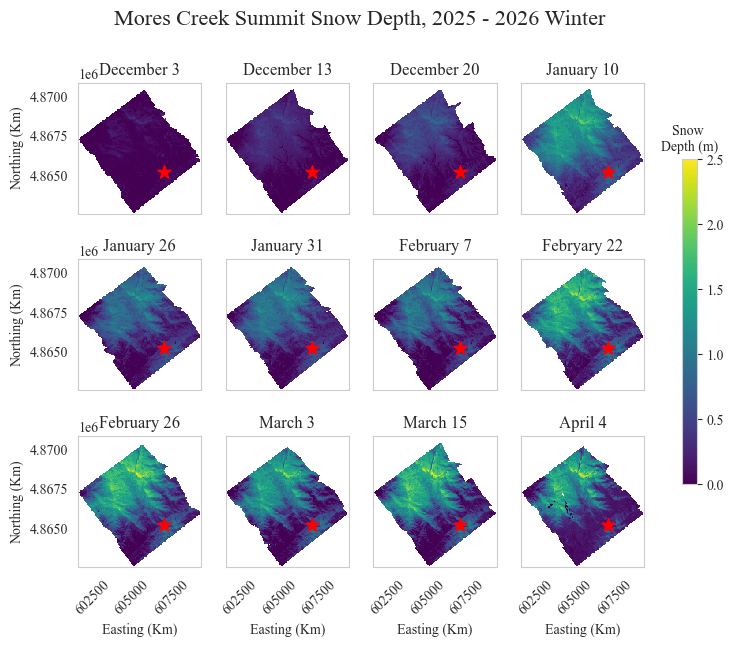

In [7]:

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']
vmin = 0
vmax = 2.5
dates = ['December 3', 'December 13','December 20', 'January 10', 'January 26', 'January 31','February 7', 'Febryary 22', 'February 26', 'March 3', 'March 15', 'April 4']

fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(7.5,6.5), sharex=True, sharey=True)
fig.subplots_adjust(right=0.88)
fig.suptitle('Mores Creek Summit Snow Depth, 2025 - 2026 Winter', fontsize=16)
for i, (date, raster) in enumerate(raster_dict.items()):
        ax = axes.flatten()[i]
        snow_depth = rxr.open_rasterio(raster, masked=True)
        im = snow_depth.plot(ax=ax, cmap='viridis', vmin=vmin, vmax=vmax, add_colorbar=False, robust=True)
        # gdf_20220217.plot(ax=ax, color='none', edgecolor='red')
        ax.scatter(607084.3493239387, 4865185.334007569, marker='*', s=100, color="red", label='SNOTEL')
        ax.set_title(dates[i])
        ax.set_aspect('equal')
        ax.set_xlabel('Easting (Km)')
        ax.set_ylabel('Northing (Km)')
        ax.tick_params(axis='x', labelrotation=45)
        ax.label_outer()  # Hides the labels of the shared axes

#cbar_ax = fig.add_axes([1, 0.3, 0.02, 0.5])
cbar_ax = fig.add_axes([0.93, 0.25, 0.02, 0.5])
cbar = fig.colorbar(im, cax=cbar_ax)
#cbar.set_label('Snow Depth (m)', fontsize=10)
cbar.ax.set_title('Snow \nDepth (m)', fontsize=10)

plt.rcParams['savefig.dpi'] = 300
#plt.tight_layout()
plt.savefig('C:/Users/RDCRLSMC/Desktop/figs/2026_snowdepth_v3.png')

plt.show()

<Figure size 640x480 with 0 Axes>

In [22]:
dir = "C:/Users/RDCRLSMC/Desktop/IDAHO_ALS/2026"

raster_dict_full = {}
for root, dirs, files in os.walk(dir):
    for filename in files:
        if "50m.tif" in filename:
            full_path = os.path.join(root, filename)
            result = filename.split("_")
            name = result[0]
            raster_dict_full[name] = os.path.abspath(full_path)

print(raster_dict_full)

{'20251203': 'C:\\Users\\RDCRLSMC\\Desktop\\IDAHO_ALS\\2026\\20251203_MCS-snowdepth_master_50m.tif', '20251213': 'C:\\Users\\RDCRLSMC\\Desktop\\IDAHO_ALS\\2026\\20251213_MCS-snowdepth_master_50m.tif', '20251220': 'C:\\Users\\RDCRLSMC\\Desktop\\IDAHO_ALS\\2026\\20251220_MCS-snowdepth_master_50m.tif', '20260110': 'C:\\Users\\RDCRLSMC\\Desktop\\IDAHO_ALS\\2026\\20260110_MCS-snowdepth_master_rerun_50m.tif', '20260126': 'C:\\Users\\RDCRLSMC\\Desktop\\IDAHO_ALS\\2026\\20260126_MCS-snowdepth_master_50m.tif', '20260131': 'C:\\Users\\RDCRLSMC\\Desktop\\IDAHO_ALS\\2026\\20260131_MCS-snowdepth_master_50m.tif', '20260207': 'C:\\Users\\RDCRLSMC\\Desktop\\IDAHO_ALS\\2026\\20260207_MCSv2-snowdepth_master_50m.tif', '20260222': 'C:\\Users\\RDCRLSMC\\Desktop\\IDAHO_ALS\\2026\\20260222_MCS-snowdepth_master_50m.tif', '20260226': 'C:\\Users\\RDCRLSMC\\Desktop\\IDAHO_ALS\\2026\\20260226_MCS-snowdepth_master_50m.tif', '20260303': 'C:\\Users\\RDCRLSMC\\Desktop\\IDAHO_ALS\\2026\\20260303_MCS-snowdepth_master_5

C:\Users\RDCRLSMC\AppData\Local\Temp\1\ipykernel_29912\1947787835.py:24: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


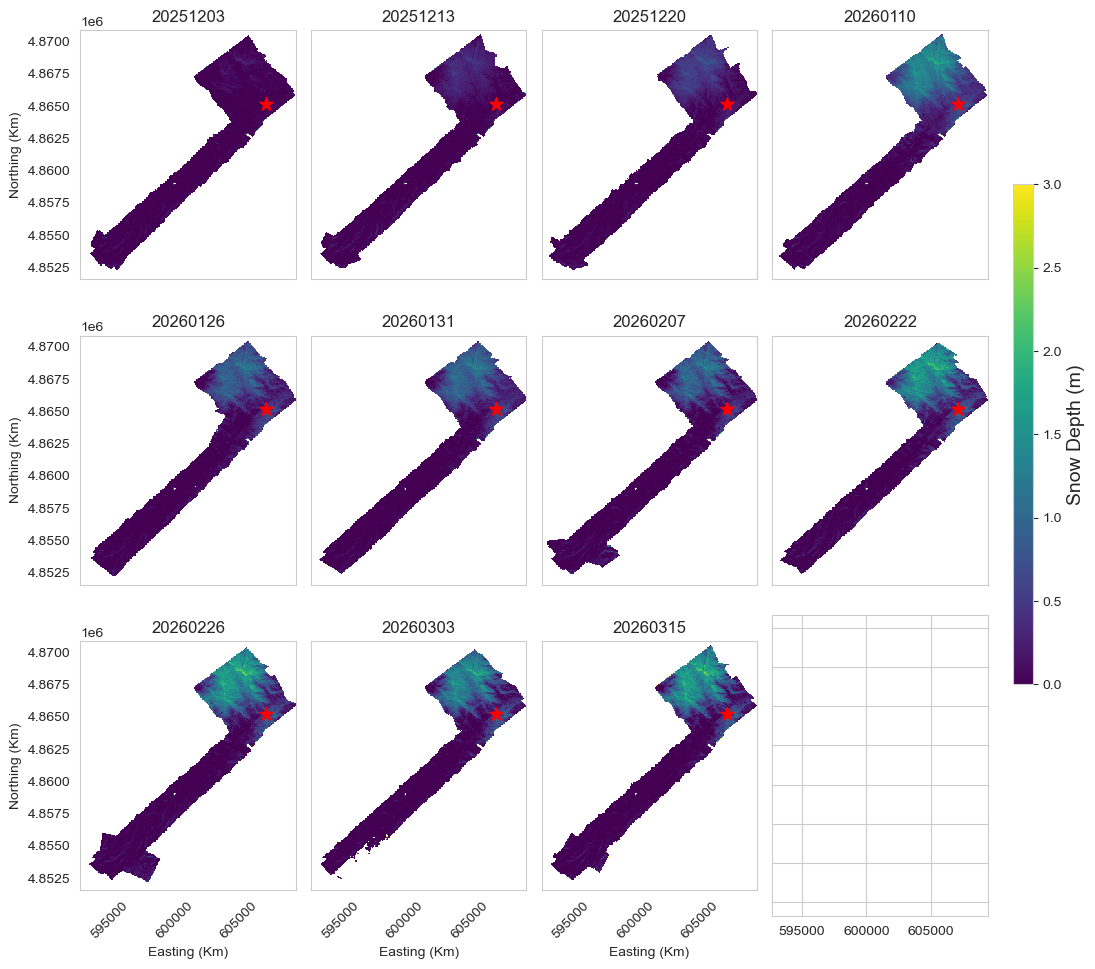

In [23]:

vmin = 0
vmax = 3


fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(10, 10), sharex=True, sharey=True)
for i, (date, raster) in enumerate(raster_dict_full.items()):
    if i < len(raster_dict_full.items()):
        ax = axes.flatten()[i]
        snow_depth = rxr.open_rasterio(raster, masked=True)
        im = snow_depth.plot(ax=ax, cmap='viridis', vmin=vmin, vmax=vmax, add_colorbar=False, robust=True)
        # gdf_20220217.plot(ax=ax, color='none', edgecolor='red')
        ax.scatter(607084.3493239387, 4865185.334007569, marker='*', s=100, color="red", label='SNOTEL')
        ax.set_title(date)
        ax.set_aspect('equal')
        ax.set_xlabel('Easting (Km)')
        ax.set_ylabel('Northing (Km)')
        ax.tick_params(axis='x', labelrotation=45)
        ax.label_outer()  # Hides the labels of the shared axes

cbar_ax = fig.add_axes([1.01, 0.3, 0.02, 0.5])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label('Snow Depth (m)', fontsize=14)

plt.tight_layout()
plt.show()